# Milestone 1: Data Preparation & Initial Analysis
**Project:** ClimateScope: Visualizing Global Weather Trends
**Author:** Ajay Bora
**Date:** February 2026

## Objective
The goal of this milestone is to prepare the "Global Weather Repository" dataset for analysis. This involves:
1.  **Data Acquisition:** Downloading the dataset via Kaggle API.
2.  **Inspection:** Understanding data types and distributions.
3.  **Cleaning:** Handling missing values, duplicates, and correct formatting.
4.  **Aggregation:** Creating a monthly summary for trend analysis.


In [ ]:
import pandas as pd
import numpy as np
import os
from kaggle.api.kaggle_api_extended import KaggleApi


DATA_FOLDER = 'data'
DATASET_SLUG = 'nelgiriyewithana/global-weather-repository'
RAW_FILE = os.path.join(DATA_FOLDER, 'GlobalWeatherRepository.csv')
CLEAN_FILE = os.path.join(DATA_FOLDER, 'cleaned_weather_data.csv')
MONTHLY_FILE = os.path.join(DATA_FOLDER, 'monthly_weather_summary.csv')
os.makedirs(DATA_FOLDER, exist_ok=True)
print(f"Directory '{DATA_FOLDER}' is ready.")

Directory 'data' is ready.


Automated Data Download. This uses your kaggle.json key.

In [21]:

api = KaggleApi()
# Check for kaggle.json key
if not os.path.exists('kaggle.json'):
    try:
        api.authenticate()
        print("Authenticated with Kaggle system credentials.")
    except Exception as e:
        print(f"Authentication failed: {e}. Please ensure 'kaggle.json' is in the project root.")
else:
    # Use local key file
    os.environ['KAGGLE_CONFIG_DIR'] = os.getcwd()
    api.authenticate()
    print("Authenticated with local kaggle.json.")

# Download Dataset into the 'data' folder
if not os.path.exists(RAW_FILE):
    print(f"Downloading {DATASET_SLUG} into '{DATA_FOLDER}'...")
    api.dataset_download_files(DATASET_SLUG, path=DATA_FOLDER, unzip=True)
    print("Download complete.")
else:
    print(f"Dataset already exists in '{DATA_FOLDER}'.")

Authenticated with local kaggle.json.
Dataset already exists in 'data'.


Load the data and inspect the structure

In [ ]:

print(f"Loading data from: {RAW_FILE}")
df = pd.read_csv(RAW_FILE)

# Display Basic Info
print(f"Dataset Shape: {df.shape}")
print("\n--- Data Types ---")
print(df.info())

print("\n--- First 5 Rows ---")
display(df.head())

Loading data from: data\GlobalWeatherRepository.csv
Dataset Shape: (124136, 41)

--- Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 124136 entries, 0 to 124135
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       124136 non-null  str    
 1   location_name                 124136 non-null  str    
 2   latitude                      124136 non-null  float64
 3   longitude                     124136 non-null  float64
 4   timezone                      124136 non-null  str    
 5   last_updated_epoch            124136 non-null  int64  
 6   last_updated                  124136 non-null  str    
 7   temperature_celsius           124136 non-null  float64
 8   temperature_fahrenheit        124136 non-null  float64
 9   condition_text                124136 non-null  str    
 10  wind_mph                      124136 non-null  float64
 11  wind_kph       

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


Statistical summary to spot anomalies.

In [23]:
# Statistical Summary of Numerical Columns
print("--- Statistical Summary ---")
display(df.describe())

# Check for Missing Values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Statistical Summary ---


,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,124136.000000,124136.000000,1.241360e+05,124136.000000,124136.000000,124136.000000,124136.000000,124136.000000,124136.000000,124136.000000,...,124136.000000,124136.000000,124136.000000,124136.000000,124136.000000,124136.000000,124136.000000,124136.000000,124136.000000,124136.000000
mean,19.193085,21.992858,1.743471e+09,21.633843,70.942661,8.070967,12.992551,169.241018,1014.059290,29.944516,...,18.309223,477.583492,58.989835,15.275060,10.698594,24.622462,49.249932,1.710841,2.635875,49.838677
std,24.426646,65.792707,1.593454e+07,9.566241,17.219092,7.379596,11.873256,103.430657,10.630259,0.313872,...,14.015566,784.126354,31.161792,24.319822,37.049426,37.901198,152.015649,0.950965,2.473284,34.979745
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,3.750000,-6.836100,1.729676e+09,16.300000,61.300000,4.000000,6.500000,80.000000,1010.000000,29.830000,...,10.400000,212.000000,39.000000,1.650000,1.050000,7.121000,10.050000,1.000000,1.000000,15.000000
50%,17.250000,23.240000,1.743500e+09,24.100000,75.400000,6.900000,11.200000,162.000000,1014.000000,29.930000,...,15.500000,303.400000,56.000000,5.450000,2.450000,14.250000,20.350000,1.000000,2.000000,50.000000
75%,40.400000,50.580000,1.757231e+09,28.100000,82.600000,11.000000,17.600000,256.000000,1018.000000,30.060000,...,24.300000,473.850000,75.000000,17.760000,8.650000,28.120000,42.200000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.771056e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000



--- Missing Values Count ---
country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone 

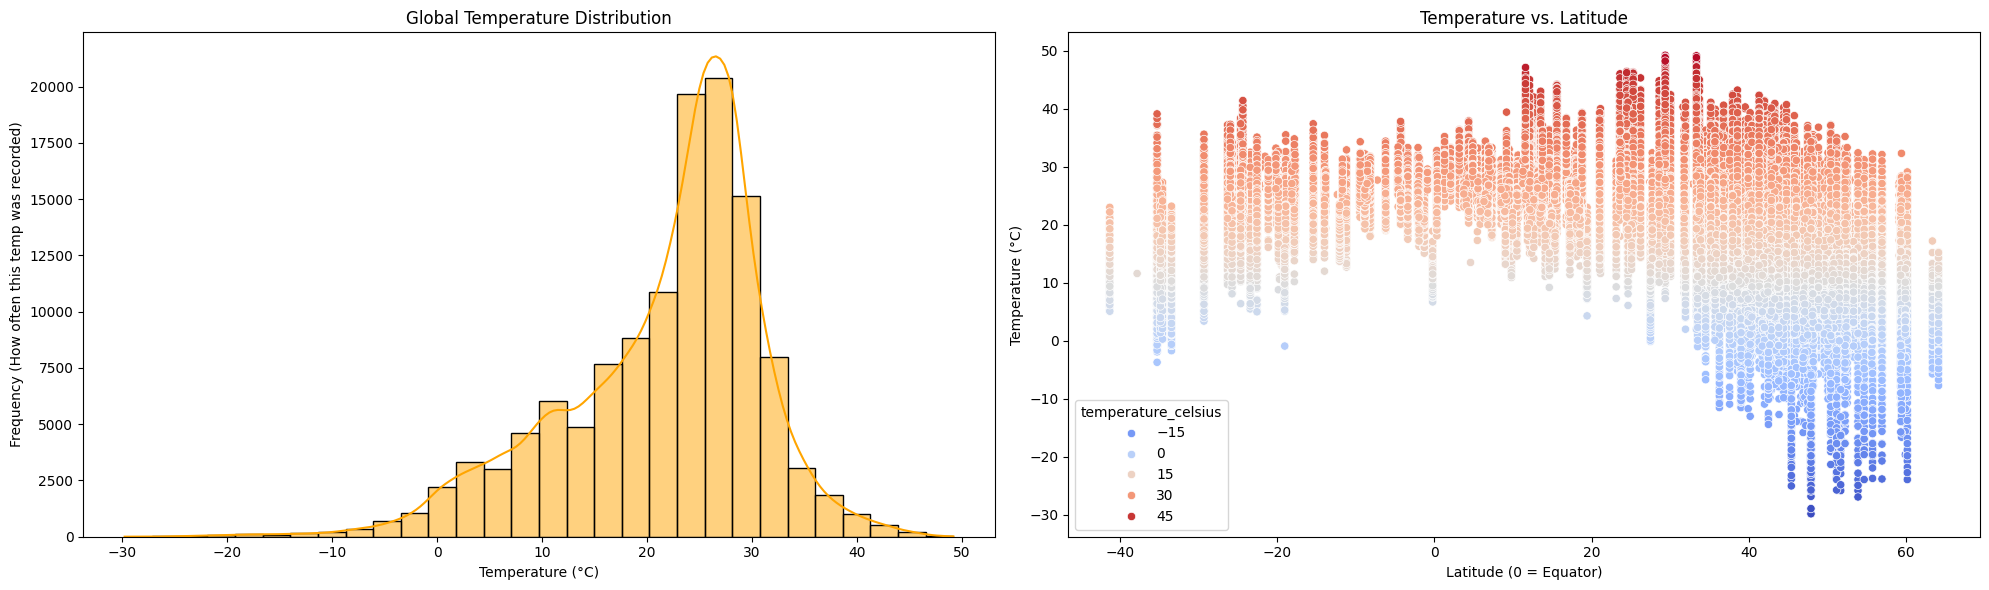

In [24]:

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# CHART 1: Global Temperature Distribution
sns.histplot(df['temperature_celsius'], kde=True, color='orange', bins=30, ax=axes[0])
axes[0].set_title('Global Temperature Distribution')
axes[0].set_xlabel('Temperature (°C)')

# THE CLEAR EXPLANATION:
axes[0].set_ylabel('Frequency (How often this temp was recorded)') 

# CHART 2: Temperature vs. Latitude
sns.scatterplot(x=df['latitude'], y=df['temperature_celsius'], hue=df['temperature_celsius'], palette='coolwarm', ax=axes[1])
axes[1].set_title('Temperature vs. Latitude')
axes[1].set_xlabel('Latitude (0 = Equator)')
axes[1].set_ylabel('Temperature (°C)')

plt.tight_layout()
plt.show()

In [ ]:

# Temperatures on Earth rarely exceed 60°C or drop below -90°C.
# This checks if there is "garbage" data.

high_temp_anomalies = df[df['temperature_celsius'] > 60]
low_temp_anomalies = df[df['temperature_celsius'] < -90]

print(f"Potential High Temp Anomalies (> 60°C): {len(high_temp_anomalies)}")
print(f"Potential Low Temp Anomalies (< -90°C): {len(low_temp_anomalies)}")

if len(high_temp_anomalies) > 0:
    display(high_temp_anomalies.head())

Potential High Temp Anomalies (> 60°C): 0
Potential Low Temp Anomalies (< -90°C): 0


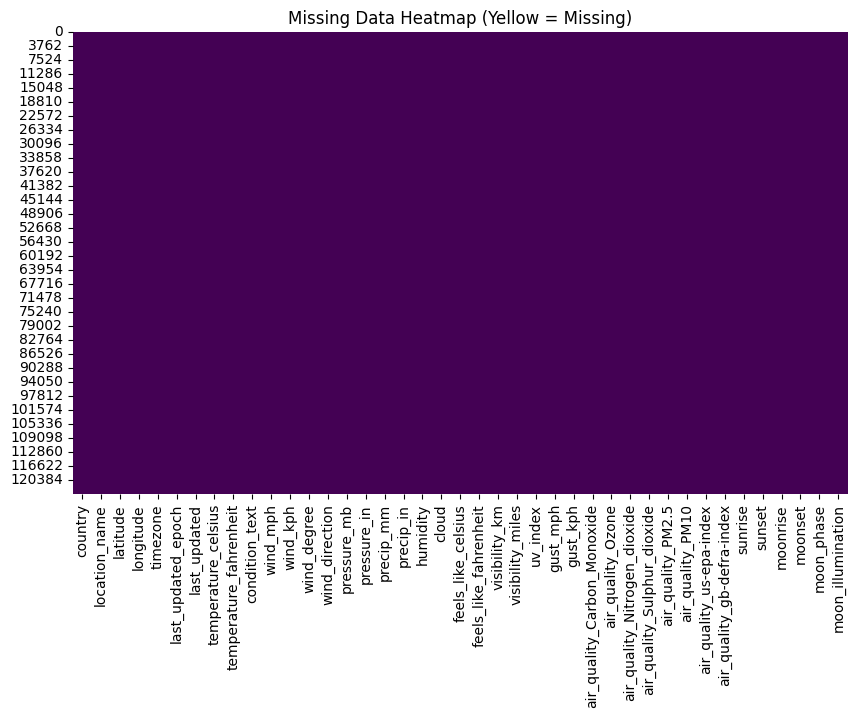

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing Missing Data
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap (Yellow = Missing)")
plt.show()

Data Cleaning: Handling duplicates, nulls, and date conversion.

In [34]:
# 1. Remove Duplicates
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_rows - len(df)} duplicate rows.")

# 2. Handle Missing Values
# Dropping rows where critical weather data is missing
df_clean = df.dropna(subset=['temperature_celsius', 'condition_text', 'country'])
print(f"Rows after dropping nulls: {len(df_clean)}")

# 3. Date Conversion
# Convert 'last_updated' column to datetime objects
if 'last_updated' in df_clean.columns:
    df_clean['last_updated'] = pd.to_datetime(df_clean['last_updated'])
    print("Converted 'last_updated' to datetime.")

Removed 0 duplicate rows.
Rows after dropping nulls: 124136
Converted 'last_updated' to datetime.


In [ ]:


# 1. Convert Units: Wind speed from km/h to m/s
# Formula: kph * (1000 meters / 3600 seconds)
df_clean['wind_mps'] = df_clean['wind_kph'] * (1000 / 3600)
print("Converted 'wind_kph' to 'wind_mps' (meters per second).")

# 2. Normalize Values: Min-Max scaling for Temperature
# Formula: (value - min) / (max - min)
temp_min = df_clean['temperature_celsius'].min()
temp_max = df_clean['temperature_celsius'].max()

df_clean['temp_normalized'] = (df_clean['temperature_celsius'] - temp_min) / (temp_max - temp_min)
print("Normalized 'temperature_celsius' to a 0.0 - 1.0 scale.")

# Display the new columns to verify
display(df_clean[['temperature_celsius', 'temp_normalized', 'wind_kph', 'wind_mps']].head())

Converted 'wind_kph' to 'wind_mps' (meters per second).
Normalized 'temperature_celsius' to a 0.0 - 1.0 scale.


,temperature_celsius,temp_normalized,wind_kph,wind_mps
0,26.6,0.713924,13.3,3.694444
1,19.0,0.617722,11.2,3.111111
2,23.0,0.668354,15.1,4.194444
3,6.3,0.456962,11.9,3.305556
4,26.0,0.706329,13.0,3.611111


Data Aggregation: Grouping by Month and Country.

In [ ]:

# Create a 'month' column to group by
df_clean['month_period'] = df_clean['last_updated'].dt.to_period('M')

# Group by Country and Month, then calculate the mean (average)
monthly_summary = df_clean.groupby(['country', 'month_period'])[[
    'temperature_celsius', 
    'temperature_fahrenheit',  # Include our new converted unit
    'precip_mm', 
    'humidity', 
    'wind_kph'
]].mean().reset_index()

print("\n--- Aggregation Complete ---")
print(f"Original Daily Rows: {len(df_clean)}")
print(f"Aggregated Monthly Rows: {len(monthly_summary)}")
display(monthly_summary.head())


--- Aggregation Complete ---
Original Daily Rows: 124136
Aggregated Monthly Rows: 4102


,country,month_period,temperature_celsius,temperature_fahrenheit,precip_mm,humidity,wind_kph
0,Afghanistan,2024-05,20.305882,68.550588,0.108824,38.058824,11.517647
1,Afghanistan,2024-06,25.590000,78.062000,0.072667,24.833333,17.110000
2,Afghanistan,2024-07,31.303448,88.346207,0.000345,17.931034,20.731034
3,Afghanistan,2024-08,30.848387,87.527097,0.037097,20.548387,20.196774
4,Afghanistan,2024-09,28.216667,82.790000,0.014333,13.733333,12.223333


Save the processed files for the next milestone.

In [29]:
# Save Cleaned Data
df_clean.to_csv(CLEAN_FILE, index=False)
print(f"Saved cleaned data to: {CLEAN_FILE}")

# Save Aggregated Summary
monthly_summary.to_csv(MONTHLY_FILE, index=False)
print(f"Saved monthly summary to: {MONTHLY_FILE}")

Saved cleaned data to: data\cleaned_weather_data.csv
Saved monthly summary to: data\monthly_weather_summary.csv
